# Notebook 18 - Final Claim via Multi-Video Aggregate

Notebook ini dibuat untuk **klaim final** kebaruan Spatial Attention AttentiveSkel3D menggunakan agregasi banyak video.

Output utama:
- Ringkasan metrik per model (lintas video)
- Komparasi sanity-check spatial attention
- Skor gabungan novelty evidence untuk menentukan model terbaik

In [34]:
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
from functools import lru_cache
from typing import Optional

import cv2
import mediapipe as mp
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

ROOT_DIR = Path.cwd().resolve().parents[0] if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
if not (ROOT_DIR / 'src').exists():
    ROOT_DIR = ROOT_DIR.parent

import sys
for _path in (str(ROOT_DIR), str(ROOT_DIR / 'src')):
    if _path not in sys.path:
        sys.path.insert(0, _path)

from src.models.model_3dcnn import AttentiveSkel3D
from web_app.frame_sync import build_frame_mapping
from web_app.attention_profiles import combine_attention, normalize_attention

# GPU/Device Configuration
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

MAX_FRAMES = 64
TOP_K = 5
TARGET_CLASS_NAMES = {0: 'Form Benar', 1: 'Form Salah'}

MODEL_SPECS = {
    'Baseline 3D-CNN': {
        'checkpoint': ROOT_DIR / 'models' / 'saved_models' / 'baseline_3dcnn_model.pth',
        'config': dict(use_spatial_prior=False, use_learned_spatial=False, use_temporal_attention=False),
    },
    'Ablasi A - Tanpa Prior': {
        'checkpoint': ROOT_DIR / 'models' / 'saved_models' / 'ablasi_a_no_prior.pth',
        'config': dict(use_spatial_prior=False, use_learned_spatial=True, use_temporal_attention=True),
    },
    'Ablasi B - Tanpa Learned Spatial': {
        'checkpoint': ROOT_DIR / 'models' / 'saved_models' / 'ablasi_b_no_learned.pth',
        'config': dict(use_spatial_prior=True, use_learned_spatial=False, use_temporal_attention=True),
    },
    'Ablasi C - Tanpa Temporal': {
        'checkpoint': ROOT_DIR / 'models' / 'saved_models' / 'ablasi_c_no_temporal.pth',
        'config': dict(use_spatial_prior=True, use_learned_spatial=True, use_temporal_attention=False),
    },
    'Full Model (Final)': {
        'checkpoint': ROOT_DIR / 'models' / 'saved_models' / 'AttentiveSkel3D_Final.pth',
        'config': dict(use_spatial_prior=True, use_learned_spatial=True, use_temporal_attention=True),
    },
}

MOVEMENT_TARGET_JOINTS = {
    'Squat': [23, 24, 25, 26],
    'Deadlift': [11, 12, 23, 24, 25, 26],
    'Bench Press': [11, 12, 13, 14, 15, 16],
}

MOVEMENT_SOURCE_DIRS = {
    'Squat': [ROOT_DIR / 'data' / 'test', ROOT_DIR / 'data' / 'raw' / 'Squat'],
    'Deadlift': [ROOT_DIR / 'data' / 'test', ROOT_DIR / 'data' / 'raw' / 'Deadlift'],
    'Bench Press': [ROOT_DIR / 'data' / 'test', ROOT_DIR / 'data' / 'raw' / 'BenchPress'],
}

# Optional label file (for classification accuracy).
# Expected columns: video_name, true_label (0/1)
OPTIONAL_LABEL_CSV = ROOT_DIR / 'data' / 'processed' / 'attention_sanity_proof' / 'video_labels.csv'

# Runtime guard: batasi jumlah video per movement bila ingin cepat saat dry-run.
MAX_VIDEOS_PER_MOVEMENT = None  # contoh: 10

OUT_DIR = ROOT_DIR / 'results' / 'model_audit' / 'aggregate_attention_claim'
OUT_DIR.mkdir(parents=True, exist_ok=True)

print('ROOT_DIR:', ROOT_DIR)
print('OUT_DIR :', OUT_DIR)

Using device: cuda
GPU: NVIDIA GeForce RTX 3060 Ti
GPU Memory: 8.6 GB
ROOT_DIR: D:\Data-Aji\KULIAH\Tugas-Akhir\AttentiveSkel3D-WeightTraining-PoC
OUT_DIR : D:\Data-Aji\KULIAH\Tugas-Akhir\AttentiveSkel3D-WeightTraining-PoC\results\model_audit\aggregate_attention_claim


In [35]:
mp_pose = mp.solutions.pose

@lru_cache(maxsize=8)
def load_model(scenario_label: str) -> AttentiveSkel3D:
    spec = MODEL_SPECS[scenario_label]
    checkpoint = Path(spec['checkpoint'])
    if not checkpoint.exists():
        raise FileNotFoundError(f'Checkpoint not found: {checkpoint}')

    model = AttentiveSkel3D(num_classes=2, **dict(spec['config']))
    try:
        ckpt = torch.load(str(checkpoint), map_location=DEVICE, weights_only=True)
    except Exception:
        ckpt = torch.load(str(checkpoint), map_location=DEVICE, weights_only=False)

    state_dict = ckpt.get('model_state_dict') if isinstance(ckpt, dict) and 'model_state_dict' in ckpt else ckpt
    if isinstance(state_dict, dict) and 'state_dict' in state_dict:
        state_dict = state_dict['state_dict']

    model.load_state_dict(state_dict, strict=False)
    model = model.to(DEVICE)
    model.eval()
    return model

def collect_videos_for_movement(movement: str) -> list[Path]:
    videos = []
    for directory in MOVEMENT_SOURCE_DIRS[movement]:
        if directory.exists():
            videos.extend(sorted(directory.glob('*.mp4')))
    unique = []
    seen = set()
    for p in videos:
        key = str(p.resolve())
        if key not in seen:
            seen.add(key)
            unique.append(p)
    if MAX_VIDEOS_PER_MOVEMENT is not None:
        unique = unique[:MAX_VIDEOS_PER_MOVEMENT]
    return unique

def build_tensor_from_video(video_path: Path, max_frames: int = MAX_FRAMES) -> tuple[torch.Tensor, int]:
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        raise FileNotFoundError(f'Cannot open video: {video_path}')

    coords_seq = []
    frame_count = 0

    with mp_pose.Pose(model_complexity=1, min_detection_confidence=0.5, min_tracking_confidence=0.5) as pose:
        while cap.isOpened():
            ret, frame_bgr = cap.read()
            if not ret:
                break
            frame_count += 1
            result = pose.process(cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB))
            if result.pose_landmarks is None:
                if coords_seq:
                    coords_seq.append(coords_seq[-1].copy())
                else:
                    coords_seq.append(np.zeros((33, 3), dtype=np.float32))
            else:
                lms = result.pose_landmarks.landmark
                coords_seq.append(np.array([[lm.x, lm.y, lm.z] for lm in lms], dtype=np.float32))

    cap.release()
    if frame_count == 0 or len(coords_seq) == 0:
        raise RuntimeError(f'No valid frames extracted: {video_path.name}')

    mapping = build_frame_mapping(frame_count, max_frames=max_frames)
    sampled_indices = list(mapping['resampled_to_source'])
    sampled_coords = [coords_seq[i] for i in sampled_indices]
    tensor = torch.tensor(np.stack(sampled_coords, axis=0), dtype=torch.float32).unsqueeze(0)
    tensor = tensor.to(DEVICE)  # Move to device
    return tensor, frame_count

def extract_prior_attention(model: AttentiveSkel3D) -> Optional[np.ndarray]:
    if not getattr(model, 'use_spatial_prior', False):
        return None
    if not hasattr(model, 'biomechanical_spatial_prior'):
        return None
    with torch.no_grad():
        w = torch.sigmoid(model.biomechanical_spatial_prior).squeeze().cpu().numpy()
    w = np.asarray(w, dtype=np.float32).reshape(-1)
    return w if w.size == 33 else None

def extract_learned_attention(model: AttentiveSkel3D, tensor_input: torch.Tensor) -> Optional[np.ndarray]:
    if not getattr(model, 'use_learned_spatial', False):
        return None
    with torch.no_grad():
        x = tensor_input.permute(0, 3, 1, 2).unsqueeze(-1).contiguous()
        if getattr(model, 'use_spatial_prior', False) and hasattr(model, 'biomechanical_spatial_prior'):
            x = x * torch.sigmoid(model.biomechanical_spatial_prior)
        x = model.conv_block_1(x)
        x = model.conv_block_2(x)
        x = model.conv_block_3(x)
        gap_feat = x.mean(dim=[2, 3, 4])
        ch_w = model.learned_spatial_attention(gap_feat)
        weighted = x * ch_w.unsqueeze(-1).unsqueeze(-1).unsqueeze(-1)
        pooled = weighted.abs().mean(dim=1).mean(dim=1).squeeze(-1)
        pooled_np = pooled.squeeze(0).detach().cpu().numpy().astype(np.float32)

    if pooled_np.size == 0:
        return None
    if pooled_np.size == 33:
        return pooled_np
    x_src = np.linspace(0.0, pooled_np.size - 1.0, pooled_np.size, dtype=np.float32)
    x_dst = np.linspace(0.0, pooled_np.size - 1.0, 33, dtype=np.float32)
    return np.interp(x_dst, x_src, pooled_np).astype(np.float32)

def select_attention(model: AttentiveSkel3D, tensor_input: torch.Tensor) -> tuple[np.ndarray, str]:
    prior = extract_prior_attention(model)
    learned = extract_learned_attention(model, tensor_input)

    if prior is not None and learned is not None:
        fused = combine_attention(prior, learned)
        if fused is not None:
            return fused.astype(np.float32), 'fused'

    if learned is not None:
        learned_norm = normalize_attention(learned, mode='global')
        if learned_norm is not None:
            return learned_norm.astype(np.float32), 'learned'

    if prior is not None:
        prior_norm = normalize_attention(prior, mode='global')
        if prior_norm is not None:
            return prior_norm.astype(np.float32), 'prior'

    return np.full(33, 0.5, dtype=np.float32), 'neutral'

In [36]:
def predict_with_confidence(model: AttentiveSkel3D, tensor_input: torch.Tensor) -> tuple[int, float]:
    with torch.no_grad():
        logits = model(tensor_input)
        probs = torch.softmax(logits, dim=-1)
        pred_class = int(logits.argmax(dim=-1).item())
        confidence = float(probs[0, pred_class].item())
    return pred_class, confidence

def compute_target_focus_metrics(attn: np.ndarray, target_joints: list[int], top_k: int = TOP_K) -> dict:
    attn = np.asarray(attn, dtype=np.float32).reshape(-1)
    target_joints = [int(i) for i in target_joints if 0 <= int(i) < attn.size]
    if len(target_joints) == 0:
        return {
            'target_focus_ratio': np.nan,
            'topk_hit_count': 0,
            'topk_hit_ratio': np.nan,
            'topk_joints': [],
        }

    attn_sum = float(np.sum(attn)) + 1e-8
    target_sum = float(np.sum(attn[target_joints]))
    target_focus_ratio = target_sum / attn_sum

    topk_idx = np.argsort(attn)[::-1][:top_k]
    hit_count = int(sum(int(i) in set(target_joints) for i in topk_idx))
    hit_ratio = hit_count / max(1, min(top_k, len(target_joints)))

    return {
        'target_focus_ratio': target_focus_ratio,
        'topk_hit_count': hit_count,
        'topk_hit_ratio': hit_ratio,
        'topk_joints': [int(i) for i in topk_idx],
    }

def compute_joint_occlusion_drops(model: AttentiveSkel3D, tensor_input: torch.Tensor, pred_class: int) -> np.ndarray:
    with torch.no_grad():
        base_logits = model(tensor_input)
        base_score = float(base_logits[0, pred_class].item())

    drops = []
    for joint_idx in range(33):
        occ = tensor_input.clone()
        occ[:, :, joint_idx, :] = 0.0
        with torch.no_grad():
            occ_logits = model(occ)
            occ_score = float(occ_logits[0, pred_class].item())
        drops.append(base_score - occ_score)

    return np.asarray(drops, dtype=np.float32)

def compute_joint_gradient_scores(model: AttentiveSkel3D, tensor_input: torch.Tensor, pred_class: int) -> np.ndarray:
    grad_input = tensor_input.clone().detach().requires_grad_(True)
    model.zero_grad(set_to_none=True)
    logits = model(grad_input)
    target_logit = logits[0, pred_class]
    target_logit.backward()

    grads = grad_input.grad.detach().cpu().numpy()[0]  # (T, 33, 3)
    joint_scores = np.mean(np.abs(grads), axis=(0, 2))      # (33,)
    return np.asarray(joint_scores, dtype=np.float32)

In [37]:
work_items = []
for movement in MOVEMENT_TARGET_JOINTS:
    videos = collect_videos_for_movement(movement)
    for video_path in videos:
        work_items.append((movement, video_path))

print(f'Total videos discovered: {len(work_items)}')
for movement in MOVEMENT_TARGET_JOINTS:
    count_m = sum(1 for m, _ in work_items if m == movement)
    print(f'- {movement}: {count_m}')

if len(work_items) == 0:
    raise RuntimeError('Tidak ada video ditemukan. Cek path pada MOVEMENT_SOURCE_DIRS.')

Total videos discovered: 507
- Squat: 173
- Deadlift: 134
- Bench Press: 200


In [38]:
rows = []
total_jobs = len(work_items) * len(MODEL_SPECS)
job_idx = 0

print(f'\n=== Processing Configuration ===')
print(f'Device: {DEVICE}')
print(f'Total jobs: {total_jobs}')
print(f'Total videos: {len(work_items)}')
print(f'Total models: {len(MODEL_SPECS)}\n')

import time
start_time = time.time()

for movement, video_path in work_items:
    target_joints = MOVEMENT_TARGET_JOINTS[movement]

    try:
        tensor_input, original_frame_count = build_tensor_from_video(video_path, max_frames=MAX_FRAMES)
    except Exception as exc:
        print(f'[SKIP] {video_path.name}: {exc}')
        continue

    for scenario_label in MODEL_SPECS:
        job_idx += 1
        if job_idx % 5 == 0 or job_idx == total_jobs:
            elapsed = time.time() - start_time
            print(f'Progress: {job_idx}/{total_jobs} ({100*job_idx//total_jobs}%) | Elapsed: {elapsed:.1f}s')

        try:
            model = load_model(scenario_label)
            pred_class, confidence = predict_with_confidence(model, tensor_input)

            attn, attn_source = select_attention(model, tensor_input)
            focus_metrics = compute_target_focus_metrics(attn, target_joints, top_k=TOP_K)

            occ_drops = compute_joint_occlusion_drops(model, tensor_input, pred_class=pred_class)
            occ_target_ratio = float(np.sum(occ_drops[target_joints]) / (np.sum(np.abs(occ_drops)) + 1e-8))

            grad_scores = compute_joint_gradient_scores(model, tensor_input, pred_class=pred_class)
            grad_target_ratio = float(np.sum(grad_scores[target_joints]) / (np.sum(grad_scores) + 1e-8))

            rows.append({
                'movement': movement,
                'video_name': video_path.name,
                'scenario': scenario_label,
                'prediction': pred_class,
                'prediction_label': TARGET_CLASS_NAMES.get(pred_class, str(pred_class)),
                'confidence': confidence,
                'attention_source': attn_source,
                'target_focus_ratio': float(focus_metrics['target_focus_ratio']),
                'topk_hit_count': int(focus_metrics['topk_hit_count']),
                'topk_hit_ratio': float(focus_metrics['topk_hit_ratio']),
                'topk_joints': ','.join(map(str, focus_metrics['topk_joints'])),
                'occlusion_target_drop_ratio': occ_target_ratio,
                'gradient_target_ratio': grad_target_ratio,
                'original_frame_count': int(original_frame_count),
                'sampled_frame_count': int(MAX_FRAMES),
            })

            # Clear GPU memory after each model to prevent OOM
            if torch.cuda.is_available():
                torch.cuda.empty_cache()

        except Exception as exc:
            print(f'[ERR] {scenario_label} | {video_path.name}: {exc}')

total_elapsed = time.time() - start_time
df_results = pd.DataFrame(rows)
print(f'\nProcessing completed in {total_elapsed:.1f}s')
print(f'Collected rows: {len(df_results)}')
df_results.head()


=== Processing Configuration ===
Device: cuda
Total jobs: 2535
Total videos: 507
Total models: 5

Progress: 5/2535 (0%) | Elapsed: 3.5s
Progress: 10/2535 (0%) | Elapsed: 8.5s
Progress: 15/2535 (0%) | Elapsed: 13.5s
Progress: 20/2535 (0%) | Elapsed: 18.1s
Progress: 25/2535 (0%) | Elapsed: 25.2s
Progress: 30/2535 (1%) | Elapsed: 29.8s
Progress: 35/2535 (1%) | Elapsed: 33.7s
Progress: 40/2535 (1%) | Elapsed: 38.7s
Progress: 45/2535 (1%) | Elapsed: 42.8s
Progress: 50/2535 (1%) | Elapsed: 48.1s
Progress: 55/2535 (2%) | Elapsed: 52.8s
Progress: 60/2535 (2%) | Elapsed: 55.9s
Progress: 65/2535 (2%) | Elapsed: 60.8s
Progress: 70/2535 (2%) | Elapsed: 66.3s
Progress: 75/2535 (2%) | Elapsed: 69.9s
Progress: 80/2535 (3%) | Elapsed: 73.6s
Progress: 85/2535 (3%) | Elapsed: 78.3s
Progress: 90/2535 (3%) | Elapsed: 82.9s
Progress: 95/2535 (3%) | Elapsed: 86.3s
Progress: 100/2535 (3%) | Elapsed: 89.6s
Progress: 105/2535 (4%) | Elapsed: 94.0s
Progress: 110/2535 (4%) | Elapsed: 97.5s
Progress: 115/2535 (4

,movement,video_name,scenario,prediction,prediction_label,confidence,attention_source,target_focus_ratio,topk_hit_count,topk_hit_ratio,topk_joints,occlusion_target_drop_ratio,gradient_target_ratio,original_frame_count,sampled_frame_count
0,Squat,primer_squat_frontal_subjek01_rep1.mp4,Baseline 3D-CNN,1,Form Salah,0.944947,neutral,0.121212,0,0.00,"32,15,1,2,3",-0.193519,0.157219,99,64
1,Squat,primer_squat_frontal_subjek01_rep1.mp4,Ablasi A - Tanpa Prior,0,Form Benar,0.996710,learned,0.151321,1,0.25,"5,6,4,7,23",0.218192,0.143781,99,64
2,Squat,primer_squat_frontal_subjek01_rep1.mp4,Ablasi B - Tanpa Learned Spatial,1,Form Salah,0.591296,prior,0.099010,0,0.00,"20,13,22,21,16",-0.141397,0.141144,99,64
3,Squat,primer_squat_frontal_subjek01_rep1.mp4,Ablasi C - Tanpa Temporal,1,Form Salah,0.999346,fused,0.197986,2,0.50,"27,28,25,26,29",-0.072688,0.140440,99,64
4,Squat,primer_squat_frontal_subjek01_rep1.mp4,Full Model (Final),1,Form Salah,0.581104,fused,0.156794,2,0.50,"26,29,25,28,27",-0.000134,0.145143,99,64


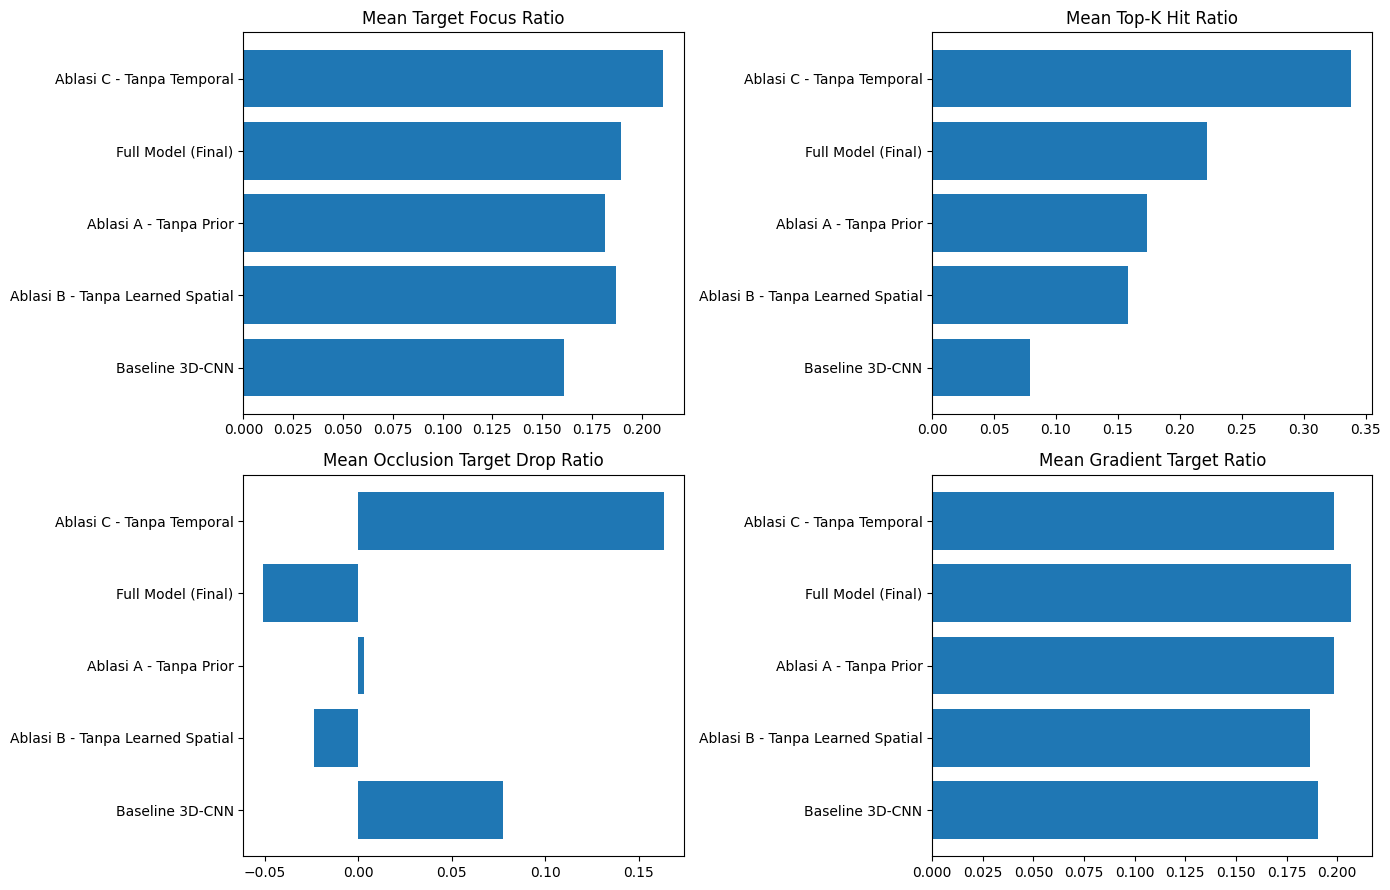

In [39]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
if 'df_model_summary' not in globals() or df_model_summary is None or df_model_summary.empty:
    metric_cols = [
        'target_focus_ratio',
        'topk_hit_ratio',
        'occlusion_target_drop_ratio',
        'gradient_target_ratio',
    ]
    missing = [c for c in metric_cols + ['scenario'] if c not in df_results.columns]
    if missing:
        raise KeyError(f'Missing required columns in df_results: {missing}')

    df_model_summary = (
        df_results
        .groupby('scenario', as_index=False)
        .agg(
            n_videos=('video_name', 'nunique'),
            target_focus_ratio_mean=('target_focus_ratio', 'mean'),
            topk_hit_ratio_mean=('topk_hit_ratio', 'mean'),
            occlusion_target_drop_ratio_mean=('occlusion_target_drop_ratio', 'mean'),
            gradient_target_ratio_mean=('gradient_target_ratio', 'mean'),
            confidence_mean=('confidence', 'mean'),
        )
    )

    if 'is_correct' in df_results.columns:
        acc = (
            df_results.groupby('scenario', as_index=False)['is_correct']
            .mean()
            .rename(columns={'is_correct': 'is_correct_mean'})
        )
        df_model_summary = df_model_summary.merge(acc, on='scenario', how='left')

    score_base_cols = [
        'target_focus_ratio_mean',
        'topk_hit_ratio_mean',
        'occlusion_target_drop_ratio_mean',
        'gradient_target_ratio_mean',
    ]
    norm_cols = []
    for col in score_base_cols:
        s = df_model_summary[col].astype(float)
        rng = float(s.max() - s.min())
        norm_col = f'{col}_norm'
        df_model_summary[norm_col] = 0.5 if rng < 1e-12 else (s - s.min()) / rng
        norm_cols.append(norm_col)

    df_model_summary['novelty_evidence_score'] = df_model_summary[norm_cols].mean(axis=1)
    df_model_summary = df_model_summary.sort_values('novelty_evidence_score', ascending=False).reset_index(drop=True)

summary = df_model_summary.copy()

axes[0, 0].barh(summary['scenario'], summary['target_focus_ratio_mean'])
axes[0, 0].set_title('Mean Target Focus Ratio')
axes[0, 0].invert_yaxis()

axes[0, 1].barh(summary['scenario'], summary['topk_hit_ratio_mean'])
axes[0, 1].set_title('Mean Top-K Hit Ratio')
axes[0, 1].invert_yaxis()

axes[1, 0].barh(summary['scenario'], summary['occlusion_target_drop_ratio_mean'])
axes[1, 0].set_title('Mean Occlusion Target Drop Ratio')
axes[1, 0].invert_yaxis()

axes[1, 1].barh(summary['scenario'], summary['gradient_target_ratio_mean'])
axes[1, 1].set_title('Mean Gradient Target Ratio')
axes[1, 1].invert_yaxis()

plt.tight_layout()
plt.show()

In [40]:
best_row = df_model_summary.iloc[0]
print('=== FINAL CLAIM CANDIDATE (Spatial Attention Novelty) ===')
print('Best model by novelty_evidence_score:', best_row['scenario'])
print('novelty_evidence_score:', round(float(best_row['novelty_evidence_score']), 4))
print('target_focus_ratio_mean:', round(float(best_row['target_focus_ratio_mean']), 4))
print('topk_hit_ratio_mean:', round(float(best_row['topk_hit_ratio_mean']), 4))
print('occlusion_target_drop_ratio_mean:', round(float(best_row['occlusion_target_drop_ratio_mean']), 4))
print('gradient_target_ratio_mean:', round(float(best_row['gradient_target_ratio_mean']), 4))

if 'is_correct_mean' in df_model_summary.columns:
    print('classification_accuracy_mean:', round(float(best_row['is_correct_mean']), 4))

df_model_summary[['scenario', 'novelty_evidence_score'] + ([ 'is_correct_mean'] if 'is_correct_mean' in df_model_summary.columns else [])]

=== FINAL CLAIM CANDIDATE (Spatial Attention Novelty) ===
Best model by novelty_evidence_score: Ablasi C - Tanpa Temporal
novelty_evidence_score: 0.8973
target_focus_ratio_mean: 0.2106
topk_hit_ratio_mean: 0.3386
occlusion_target_drop_ratio_mean: 0.1634
gradient_target_ratio_mean: 0.1986


,scenario,novelty_evidence_score
0,Ablasi C - Tanpa Temporal,0.897281
1,Full Model (Final),0.532302
2,Ablasi A - Tanpa Prior,0.402151
3,Ablasi B - Tanpa Learned Spatial,0.239769
4,Baseline 3D-CNN,0.197988


In [41]:
raw_csv = OUT_DIR / 'aggregate_per_video_results.csv'
summary_csv = OUT_DIR / 'aggregate_model_summary.csv'

df_results.to_csv(raw_csv, index=False)
df_model_summary.to_csv(summary_csv, index=False)

print('Saved:', raw_csv)
print('Saved:', summary_csv)

Saved: D:\Data-Aji\KULIAH\Tugas-Akhir\AttentiveSkel3D-WeightTraining-PoC\results\model_audit\aggregate_attention_claim\aggregate_per_video_results.csv
Saved: D:\Data-Aji\KULIAH\Tugas-Akhir\AttentiveSkel3D-WeightTraining-PoC\results\model_audit\aggregate_attention_claim\aggregate_model_summary.csv


## Cara Pakai Untuk Klaim Final

1. Jalankan semua cell berurutan.
2. Gunakan output `aggregate_model_summary.csv` sebagai tabel utama sidang.
3. Fokus pada metrik spatial sanity-check:
   - `target_focus_ratio_mean`
   - `topk_hit_ratio_mean`
   - `occlusion_target_drop_ratio_mean`
   - `gradient_target_ratio_mean`
4. Model terbaik untuk novelty claim adalah skor `novelty_evidence_score` tertinggi.
5. Jika punya ground truth label, isi `video_labels.csv` agar bisa menambahkan metrik akurasi klasifikasi.